In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,roc_auc_score,auc,accuracy_score

<h2>Read Data</h2>

In [2]:
df=pd.read_csv("./Data/train_data.csv")
df.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,0
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,0
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,0
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,0
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,0


In [4]:
df['class'].value_counts()

0    40
1    40
2    40
Name: class, dtype: int64

In [5]:
y=df['class']
X=df.drop(labels="class",axis=1)
X.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,5.094305,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.641339,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,6.453880,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,1.945784,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,4.978558,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550


In [8]:
print(X.shape)
print(y.shape)

(120, 22)
(120,)


<h2> Pre-processing train data</h2>

In [9]:
cols=X.columns
scaler=StandardScaler()
X_train=pd.DataFrame(scaler.fit_transform(X),columns=cols)
X_train.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.103789,1.135458,-0.068860,-0.068860,0.631463,1.188720,0.744575,-0.417389,0.552925,-0.584817,...,0.126660,0.142939,0.086579,0.511936,1.135458,0.831089,0.829870,0.635882,-0.686903,-1.076539
1,-0.680372,-0.096930,-0.590980,-0.590980,0.288586,0.518011,-0.536722,0.727370,-0.678133,0.647681,...,-0.672298,-0.704388,-0.627683,-0.687257,-0.096930,-0.518169,0.648174,-0.583856,0.581419,0.209637
2,0.520681,2.596747,-0.363470,-0.363470,1.326454,1.804441,1.322993,-0.624613,0.800081,-0.909542,...,0.569488,0.496156,0.599601,0.731857,2.596747,1.210846,1.449196,0.662878,-1.158663,-2.304490
3,-0.899305,-0.586223,-1.603131,-1.603131,-1.113906,-0.796778,-0.746084,0.868106,-0.859438,0.786830,...,-0.898848,-0.883758,-0.926553,-0.873852,-0.586223,-0.731061,0.969384,-0.959816,0.758550,0.606726
4,0.055406,1.564583,-0.151808,-0.151808,1.947260,2.430295,0.515526,0.013004,0.099613,-0.181000,...,0.088959,-0.017247,0.234410,0.072233,1.564583,0.507380,1.043203,0.242510,-0.384961,-1.338453


In [12]:
X_train.describe().apply(lambda s:s.apply('{0:.5f}'.format))

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
count,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,...,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000
mean,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,0.00000,...,-0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000
std,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,...,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419
min,-1.10782,-1.71325,-3.25142,-3.25142,-1.85066,-1.88742,-1.45906,-1.63607,-1.39430,-1.92654,...,-1.12825,-1.11484,-1.14304,-1.38843,-1.71325,-1.66166,-2.71528,-2.16523,-1.95276,-2.30449
25%,-0.84141,-0.72594,-0.71643,-0.71643,-0.71068,-0.73506,-0.88587,-1.18085,-0.93072,-0.91649,...,-0.84597,-0.86967,-0.81486,-0.92665,-0.72594,-0.91464,-0.62578,-0.85113,-0.84385,-0.78033
50%,-0.49025,-0.03014,0.29667,0.29667,-0.12936,-0.17730,-0.20096,0.33584,-0.29086,0.27402,...,-0.47507,-0.48426,-0.46897,-0.30061,-0.03014,-0.05804,0.11575,0.01612,0.22050,0.04977
75%,0.94049,0.73300,0.74875,0.74875,0.63854,0.56298,0.82877,0.93264,1.03107,0.91376,...,0.92337,1.07730,0.81028,1.06398,0.73300,0.89910,0.73559,1.11472,0.89683,0.75780
max,2.52279,2.59675,1.59095,1.59095,3.58591,3.39018,1.95489,1.28409,1.78031,1.34333,...,2.49454,2.10580,3.11322,1.74849,2.59675,1.67822,2.55872,1.27789,1.41853,1.66159


In [14]:
X_train.shape

(120, 22)

<h2>Training Artifical Neural Network Model</h2>

In [47]:
model=tf.keras.Sequential()
#28 neurons output 22 input feature vector size
model.add(tf.keras.layers.Dense(units=28,activation='relu',input_shape=(22,)))

In [48]:
#adding dropout for regularization
model.add(tf.keras.layers.Dropout(0.2))

In [49]:
#adding output layer
model.add(tf.keras.layers.Dense(units=3,activation='softmax'))

In [50]:
#compile model
model.compile(optimizer="adam",loss = 'sparse_categorical_crossentropy',metrics = ['sparse_categorical_accuracy'])

In [51]:
#fitting the model
model.fit(X_train,y,epochs=100)

Epoch 1/100
4/4 [==============================] - 0s 1ms/step - loss: 1.6554 - sparse_categorical_accuracy: 0.0083
Epoch 2/100
4/4 [==============================] - 0s 1ms/step - loss: 1.4307 - sparse_categorical_accuracy: 0.0917
Epoch 3/100
4/4 [==============================] - 0s 1ms/step - loss: 1.2656 - sparse_categorical_accuracy: 0.1833
Epoch 4/100
4/4 [==============================] - 0s 1ms/step - loss: 1.1525 - sparse_categorical_accuracy: 0.3167
Epoch 5/100
4/4 [==============================] - 0s 982us/step - loss: 1.0135 - sparse_categorical_accuracy: 0.4667
Epoch 6/100
4/4 [==============================] - 0s 1ms/step - loss: 0.9360 - sparse_categorical_accuracy: 0.5250
Epoch 7/100
4/4 [==============================] - 0s 2ms/step - loss: 0.8367 - sparse_categorical_accuracy: 0.6000
Epoch 8/100
4/4 [==============================] - 0s 1ms/step - loss: 0.8626 - sparse_categorical_accuracy: 0.6000
Epoch 9/100
4/4 [==============================] - 0s 2ms/step - loss:

4/4 [==============================] - 0s 1ms/step - loss: 0.2629 - sparse_categorical_accuracy: 0.8917
Epoch 71/100
4/4 [==============================] - 0s 1ms/step - loss: 0.2564 - sparse_categorical_accuracy: 0.8833
Epoch 72/100
4/4 [==============================] - 0s 961us/step - loss: 0.2588 - sparse_categorical_accuracy: 0.9000
Epoch 73/100
4/4 [==============================] - 0s 1ms/step - loss: 0.2638 - sparse_categorical_accuracy: 0.9167
Epoch 74/100
4/4 [==============================] - 0s 1ms/step - loss: 0.2709 - sparse_categorical_accuracy: 0.8833
Epoch 75/100
4/4 [==============================] - 0s 894us/step - loss: 0.2643 - sparse_categorical_accuracy: 0.8917
Epoch 76/100
4/4 [==============================] - 0s 2ms/step - loss: 0.2461 - sparse_categorical_accuracy: 0.9167
Epoch 77/100
4/4 [==============================] - 0s 963us/step - loss: 0.2613 - sparse_categorical_accuracy: 0.9083
Epoch 78/100
4/4 [==============================] - 0s 911us/step - los

<h2>Accuracy of model on training set</h2>

In [52]:
df2=pd.read_csv("./Data/test_data.csv")
df2.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,0
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,0
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,0
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,0
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,0


In [53]:
df2.shape

(192, 23)

In [54]:
df['class'].value_counts()

0    40
1    40
2    40
Name: class, dtype: int64

In [55]:
y_test=df['class']
X_test=df.drop(labels="class",axis=1)
X_test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,5.094305,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.641339,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,6.453880,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,1.945784,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,4.978558,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550


In [56]:
#transforming data
scaler=StandardScaler()
columns=X_test.columns
X_test=pd.DataFrame(scaler.fit_transform(X_test),columns=columns)
X_test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.103789,1.135458,-0.068860,-0.068860,0.631463,1.188720,0.744575,-0.417389,0.552925,-0.584817,...,0.126660,0.142939,0.086579,0.511936,1.135458,0.831089,0.829870,0.635882,-0.686903,-1.076539
1,-0.680372,-0.096930,-0.590980,-0.590980,0.288586,0.518011,-0.536722,0.727370,-0.678133,0.647681,...,-0.672298,-0.704388,-0.627683,-0.687257,-0.096930,-0.518169,0.648174,-0.583856,0.581419,0.209637
2,0.520681,2.596747,-0.363470,-0.363470,1.326454,1.804441,1.322993,-0.624613,0.800081,-0.909542,...,0.569488,0.496156,0.599601,0.731857,2.596747,1.210846,1.449196,0.662878,-1.158663,-2.304490
3,-0.899305,-0.586223,-1.603131,-1.603131,-1.113906,-0.796778,-0.746084,0.868106,-0.859438,0.786830,...,-0.898848,-0.883758,-0.926553,-0.873852,-0.586223,-0.731061,0.969384,-0.959816,0.758550,0.606726
4,0.055406,1.564583,-0.151808,-0.151808,1.947260,2.430295,0.515526,0.013004,0.099613,-0.181000,...,0.088959,-0.017247,0.234410,0.072233,1.564583,0.507380,1.043203,0.242510,-0.384961,-1.338453


In [57]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)

4/4 [==============================] - 0s 1ms/step - loss: 0.2241 - sparse_categorical_accuracy: 0.9000


In [76]:
#get predictions
predictions=model.predict(X_test)
predictions=tf.argmax(predictions,axis=1)
predictions

<tf.Tensor: shape=(120,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2])>

In [77]:
predictions=np.array(predictions)
# predictions=pd.DataFrame(predictions,columns=["output"])
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [67]:
#important functions
def plot_matrix(y_test,predictions,filepath):
    matrix=confusion_matrix(y_test,predictions)
    matrix=matrix.transpose()
    cm_df=pd.DataFrame(matrix,index=["Early Blight","Late Blight","Healthy"],columns=["Early Blight","Late Blight","Healthy"])
    sns.heatmap(cm_df,annot_kws={"size":16},annot=True,fmt="d")
    plt.savefig(filepath,dpi=400)
    
#roc curve plotter
def plot_roc(y_test,predictions,save_path):
    actual_vals=pd.DataFrame(pd.get_dummies(y_test))
    predictions=pd.DataFrame(pd.get_dummies(predictions))
    print(predictions)
    print('0: {}'.format(predictions[predictions[0]==1][0].sum()))
    print('1 :{}'.format(predictions[predictions[1]==1][1].sum()))
    print('2 :{}'.format(predictions[predictions[2]==1][2].sum()))
    predictions.head()
    #compute roc curve and roc area for each curve
    fpr=dict()
    tpr=dict()
    roc_auc=dict()
    n_classes=3

    #loop for each class
    for i in range(n_classes):
        fpr[i],tpr[i],_=roc_curve(actual_vals.iloc[:,i],predictions.iloc[:,i])
        roc_auc[i]=auc(fpr[i],tpr[i])
    #micro-average roc curve
    fpr["micro"],tpr["micro"],_=roc_curve(actual_vals.to_numpy().ravel(),predictions.to_numpy().ravel())
    roc_auc["micro"]=auc(fpr["micro"],tpr["micro"])
    
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    #main plotter
    lw=2
    plt.figure(figsize=(10,8))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    labels=['EB','LB','H']
    for i,color in zip(range(n_classes),colors):
         plt.plot(fpr[i], tpr[i], color=color,lw=lw,label='ROC curve of class {0} {name} (area = {area:0.2f})'
                 ''.format(i, name=labels[i],area=roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for tomato disease classification')
    plt.legend(loc="lower right")
    # plt.show()
    plt.savefig(save_path,dpi=400)

<h2>Confusion Matrix</h2>

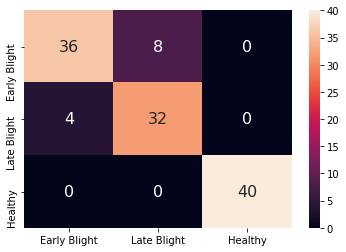

In [78]:
plot_matrix(y_test,predictions,"./images/Ann Relu Activation/ConfMatrixANN_RELU.png")

<h2>ROC Curve</h2>

0: 44
1 :36
2 :40


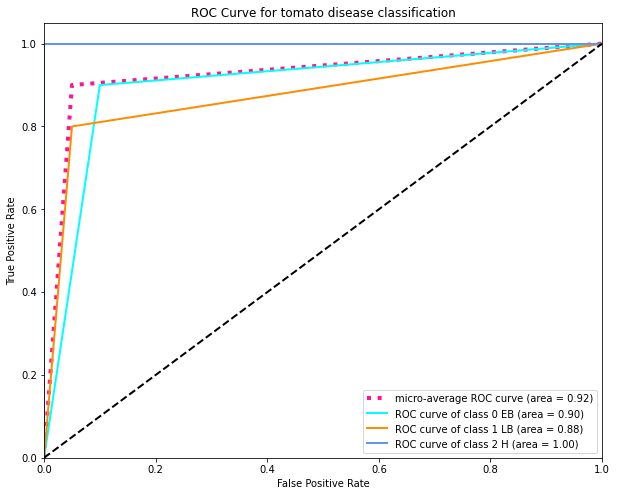

In [80]:
plot_roc(y_test,predictions,"./images/Ann Relu Activation/Roc_ANN_RELU.png")

<h2>Sigmoid Activation</h2>

<h2> Training ann using sigmoid activation</h2>

In [81]:
model=tf.keras.Sequential()
#28 neurons output 22 input feature vector size
model.add(tf.keras.layers.Dense(units=28,activation='sigmoid',input_shape=(22,)))

In [82]:
#adding dropout for regularization
model.add(tf.keras.layers.Dropout(0.2))

In [83]:
#adding output layer
model.add(tf.keras.layers.Dense(units=3,activation='softmax'))

In [84]:
#compile model
model.compile(optimizer="adam",loss = 'sparse_categorical_crossentropy',metrics = ['sparse_categorical_accuracy'])

In [85]:
#fitting the model
model.fit(X_train,y,epochs=100)

Epoch 1/100
4/4 [==============================] - 0s 1ms/step - loss: 1.4675 - sparse_categorical_accuracy: 0.3333
Epoch 2/100
4/4 [==============================] - 0s 979us/step - loss: 1.3370 - sparse_categorical_accuracy: 0.3333
Epoch 3/100
4/4 [==============================] - 0s 1ms/step - loss: 1.2769 - sparse_categorical_accuracy: 0.3750
Epoch 4/100
4/4 [==============================] - 0s 1ms/step - loss: 1.1763 - sparse_categorical_accuracy: 0.4083
Epoch 5/100
4/4 [==============================] - 0s 1ms/step - loss: 1.1462 - sparse_categorical_accuracy: 0.4500
Epoch 6/100
4/4 [==============================] - 0s 1ms/step - loss: 1.0966 - sparse_categorical_accuracy: 0.5000
Epoch 7/100
4/4 [==============================] - 0s 959us/step - loss: 1.0060 - sparse_categorical_accuracy: 0.5167
Epoch 8/100
4/4 [==============================] - 0s 2ms/step - loss: 0.9461 - sparse_categorical_accuracy: 0.5833
Epoch 9/100
4/4 [==============================] - 0s 2ms/step - los

4/4 [==============================] - 0s 1ms/step - loss: 0.3633 - sparse_categorical_accuracy: 0.8917
Epoch 71/100
4/4 [==============================] - 0s 1ms/step - loss: 0.3586 - sparse_categorical_accuracy: 0.8833
Epoch 72/100
4/4 [==============================] - 0s 998us/step - loss: 0.3763 - sparse_categorical_accuracy: 0.8583
Epoch 73/100
4/4 [==============================] - 0s 980us/step - loss: 0.3559 - sparse_categorical_accuracy: 0.9083
Epoch 74/100
4/4 [==============================] - 0s 1ms/step - loss: 0.3557 - sparse_categorical_accuracy: 0.9167
Epoch 75/100
4/4 [==============================] - 0s 961us/step - loss: 0.3658 - sparse_categorical_accuracy: 0.8667
Epoch 76/100
4/4 [==============================] - 0s 1ms/step - loss: 0.4058 - sparse_categorical_accuracy: 0.8500
Epoch 77/100
4/4 [==============================] - 0s 962us/step - loss: 0.3604 - sparse_categorical_accuracy: 0.9000
Epoch 78/100
4/4 [==============================] - 0s 1ms/step - los

<h2>Accuracy of model</h2>

In [86]:
X_test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.103789,1.135458,-0.068860,-0.068860,0.631463,1.188720,0.744575,-0.417389,0.552925,-0.584817,...,0.126660,0.142939,0.086579,0.511936,1.135458,0.831089,0.829870,0.635882,-0.686903,-1.076539
1,-0.680372,-0.096930,-0.590980,-0.590980,0.288586,0.518011,-0.536722,0.727370,-0.678133,0.647681,...,-0.672298,-0.704388,-0.627683,-0.687257,-0.096930,-0.518169,0.648174,-0.583856,0.581419,0.209637
2,0.520681,2.596747,-0.363470,-0.363470,1.326454,1.804441,1.322993,-0.624613,0.800081,-0.909542,...,0.569488,0.496156,0.599601,0.731857,2.596747,1.210846,1.449196,0.662878,-1.158663,-2.304490
3,-0.899305,-0.586223,-1.603131,-1.603131,-1.113906,-0.796778,-0.746084,0.868106,-0.859438,0.786830,...,-0.898848,-0.883758,-0.926553,-0.873852,-0.586223,-0.731061,0.969384,-0.959816,0.758550,0.606726
4,0.055406,1.564583,-0.151808,-0.151808,1.947260,2.430295,0.515526,0.013004,0.099613,-0.181000,...,0.088959,-0.017247,0.234410,0.072233,1.564583,0.507380,1.043203,0.242510,-0.384961,-1.338453


In [87]:
y_test

0      0
1      0
2      0
3      0
4      0
      ..
115    2
116    2
117    2
118    2
119    2
Name: class, Length: 120, dtype: int64

In [88]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)

4/4 [==============================] - 0s 993us/step - loss: 0.2949 - sparse_categorical_accuracy: 0.9083


In [89]:
#get predictions
predictions=model.predict(X_test)
predictions=tf.argmax(predictions,axis=1)
predictions

<tf.Tensor: shape=(120,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2])>

In [90]:
predictions=np.array(predictions)
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

<h2>Confusion Matrix</h2>

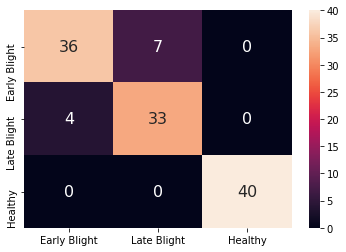

In [91]:
plot_matrix(y_test,predictions,"./images/Ann sigmoid Activation/ConfMatrixANN_Sigmoid.png")

<h2>ROC Curve</h2>

0: 43
1 :37
2 :40


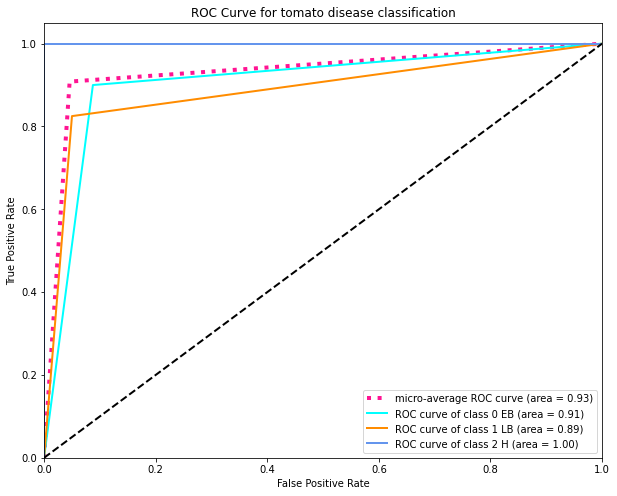

In [92]:
plot_roc(y_test,predictions,"./images/Ann sigmoid Activation/ROC_ANN_Sigmoid.png")